# Match Result Classification — Preprocessing Pipeline

**Target variable:** `result` (H = Home Win, A = Away Win, D = Draw)

This notebook produces **two outputs**:

| DataFrame | Description |
|---|---|
| `df_preprocessed` | Full in-match pipeline — all original features, cleaned, encoded, and scaled (correct chronological split) |
| `df_sliding` | Pre-match pipeline — in-match stats removed, replaced with rolling/sliding-window historical features (window = 5 matches), scaled (correct chronological split) |

**Pipeline steps:**
1. Load & Inspect
2. Row Filtering — drop rows with >40% missing
3. Drop outcome & identifier columns (team names preserved separately for rolling features)
4. Re-check column-level missingness
5. Handle missing values (median / mode imputation)
6. Datetime & time feature extraction
7. Feature engineering
8. Categorical encoding
9. Final checks
10. Produce `df_preprocessed` — correct chronological split + scaling
11. Produce `df_sliding` — rolling window features + correct chronological split + scaling
12. Save outputs

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

---
## 1. Load & Inspect

In [37]:
# Update this path if the CSV is in a different location
DATA_PATH = 'scraped_dataset.csv'  

df = pd.read_csv(DATA_PATH, low_memory=False)

print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes.value_counts())
print('\nTarget distribution:')
print(df['result'].value_counts())
df.head(3)


Shape: (16688, 109)

Column dtypes:
float64    92
object     13
int64       4
Name: count, dtype: int64

Target distribution:
result
H    7457
A    5114
D    4115
Name: count, dtype: int64


,match_id,league_division,season,round,date,kickoff_time,attendance,capacity,stadium,city,home_team,away_team,home_goals,away_goals,result,home_formation,away_formation,home_team_rating,away_team_rating,home_shots_total,away_shots_total,home_shots_on_target,away_shots_on_target,home_shots_off_target,away_shots_off_target,home_shots_inside_box,away_shots_inside_box,home_shots_outside_box,away_shots_outside_box,home_headed_goals,away_headed_goals,home_hit_woodwork,away_hit_woodwork,home_corners,away_corners,home_free_kicks,away_free_kicks,home_throw_ins,away_throw_ins,home_fouls_committed,away_fouls_committed,home_offsides,away_offsides,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards,home_goalkeeper_saves,away_goalkeeper_saves,home_possession_pct,away_possession_pct,home_touches_opp_box,away_touches_opp_box,home_passes_pct,away_passes_pct,home_passes_successful,away_passes_successful,home_passes_total,away_passes_total,home_long_passes_pct,away_long_passes_pct,home_long_passes_successful,away_long_passes_successful,home_long_passes_total,away_long_passes_total,home_passes_final_third_pct,away_passes_final_third_pct,home_passes_final_third_successful,away_passes_final_third_successful,home_passes_final_third_total,away_passes_final_third_total,home_crosses_pct,away_crosses_pct,home_crosses_successful,away_crosses_successful,home_crosses_total,away_crosses_total,home_big_chances,away_big_chances,home_duels_won,away_duels_won,home_errors_leading_to_shot,away_errors_leading_to_shot,home_errors_leading_to_goal,away_errors_leading_to_goal,home_accurate_through_passes,away_accurate_through_passes,home_tackles_pct,away_tackles_pct,home_tackles_successful,away_tackles_successful,home_tackles_total,away_tackles_total,home_shots_blocked,away_shots_blocked,home_clearances,away_clearances,home_interceptions,away_interceptions,home_xg,away_xg,home_xgot,away_xgot,home_xa,away_xa,home_xgot_faced,away_xgot_faced,home_goals_prevented,away_goals_prevented
0,Ghrg3y4k,CAF Champions League,2024-2025,Semi-finals,"August 24, 2024",05:00 PM,NaN,NaN,NaN,NaN,Jwaneng Galaxy (Bot),African Stars (Nam),2.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KMdN8ctS,CAF Champions League,2024-2025,Semi-finals,"August 17, 2024",04:00 PM,NaN,NaN,NaN,NaN,African Stars (Nam),Jwaneng Galaxy (Bot),1.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8dbp3ZfU,CAF Champions League,2024-2025,Quarter-finals,"April 01, 2025",09:00 PM,NaN,30000.0,Al Salam Stadium,Cairo,Al Ahly,Al-Hilal Omdurman,1.0,0.0,H,4-2-3-1,4-2-3-1,6.9,8.1,12.0,6.0,4.0,2.0,6.0,4.0,9.0,3.0,3.0,3.0,NaN,NaN,0.0,0.0,8.0,2.0,7.0,22.0,20.0,17.0,22.0,7.0,1.0,1.0,3,1,0,0,2.0,3.0,68.0,32.0,26.0,7.0,85.0,60.0,450.0,147.0,527.0,247.0,50.0,23.0,30.0,13.0,60.0,56.0,79.0,49.0,122.0,39.0,154.0,79.0,32.0,0.0,7.0,0.0,22.0,6.0,1.0,0.0,56.0,64.0,0.0,0.0,0.0,0.0,0.0,0.0,47.0,74.0,8.0,17.0,17.0,23.0,2.0,0.0,10.0,13.0,11.0,12.0,0.77,0.16,1.29,0.19,1.1,0.16,0.19,1.29,0.19,0.29


---
## 2. Row Filtering — Drop Rows with >40% Missing Columns

**Decision on >20% threshold:**  
Rows with 20–40% missing are kept. Those rows still have core match stats intact (possession, shots, cards, etc.);  
what's missing is mainly advanced metrics (xG, long-pass breakdowns, errors leading to shot).  
Dropping them would waste ~2,651 additional rows for no benefit — those columns will be handled by imputation.

Also dropping the 1 row where `result` is null (target is missing — unusable) and the 1 row where `date` is null.

In [38]:
# Row-level missing percentage
row_missing_pct = df.isnull().mean(axis=1)

print('--- Row-level missing summary (before filtering) ---')
print(f'Total rows:                       {len(df):>6}')
print(f'Complete rows (0% missing):       {(row_missing_pct == 0).sum():>6}')
print(f'Rows with >=1 missing:            {(row_missing_pct > 0).sum():>6}')
print(f'Rows with >20% missing columns:   {(row_missing_pct > 0.20).sum():>6}')
print(f'Rows with >40% missing columns:   {(row_missing_pct > 0.40).sum():>6}')
print(f'Rows with >50% missing columns:   {(row_missing_pct > 0.50).sum():>6}')
print(f'Rows with >80% missing columns:   {(row_missing_pct > 0.80).sum():>6}')


--- Row-level missing summary (before filtering) ---
Total rows:                        16688
Complete rows (0% missing):         2758
Rows with >=1 missing:             13930
Rows with >20% missing columns:     7284
Rows with >40% missing columns:     4633
Rows with >50% missing columns:     4129
Rows with >80% missing columns:      459


In [39]:
# Drop rows with >40% missing
df = df[row_missing_pct <= 0.40].copy()

# Drop the single rows where target or date is null
df = df.dropna(subset=['result', 'date'])

print('Shape after row filtering:', df.shape)
print('Target distribution:')
print(df['result'].value_counts())


Shape after row filtering: (12054, 109)
Target distribution:
result
H    5385
A    3679
D    2990
Name: count, dtype: int64


---
## 3. Drop Outcome & Identifier Columns

**Outcome columns — data leakage (dropped):**
- `home_goals`, `away_goals` — directly encode the result; keeping them would let any model trivially solve the task.
- `home_headed_goals`, `away_headed_goals` — subset of goals, same issue.

**Identifier / high-cardinality columns (dropped):**
- `match_id` — unique per row, no signal.
- `home_team`, `away_team` — ~1,289 / 1,281 unique values. Too high-cardinality for direct encoding.  
  Drop now; revisit when you add sliding window team-level features later.
- `stadium`, `city` — ~1,350 / 1,007 unique values, same reason.


In [40]:
outcome_cols    = ['home_goals', 'away_goals', 'home_headed_goals', 'away_headed_goals']
identifier_cols = ['match_id', 'stadium', 'city']

# Keep home_team / away_team in df for now — needed to compute rolling features.
# They will be dropped AFTER rolling features are computed in Section 11.
drop_cols = outcome_cols + identifier_cols
df.drop(columns=drop_cols, inplace=True)

print('Dropped:', drop_cols)
print('home_team and away_team are kept for rolling feature computation.')
print('Shape after dropping:', df.shape)

Dropped: ['home_goals', 'away_goals', 'home_headed_goals', 'away_headed_goals', 'match_id', 'stadium', 'city']
home_team and away_team are kept for rolling feature computation.
Shape after dropping: (12054, 102)


---
## 4. Re-check Column-Level Missingness

After row filtering the per-column missing % changes — always re-check before deciding imputation strategy.


In [41]:
missing_counts = df.isnull().sum()
missing_pct    = (missing_counts / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct':   missing_pct
}).sort_values('missing_pct', ascending=False)

missing_report = missing_report[missing_report['missing_count'] > 0]

print('Columns with at least 1 missing value:', len(missing_report))
missing_report


Columns with at least 1 missing value: 57


,missing_count,missing_pct
home_errors_leading_to_goal,2752,22.83
away_errors_leading_to_goal,2752,22.83
home_errors_leading_to_shot,2734,22.68
away_errors_leading_to_shot,2734,22.68
away_accurate_through_passes,2718,22.55
home_accurate_through_passes,2718,22.55
home_long_passes_pct,2652,22.00
away_long_passes_pct,2652,22.00
home_long_passes_total,2652,22.00
away_long_passes_total,2652,22.00


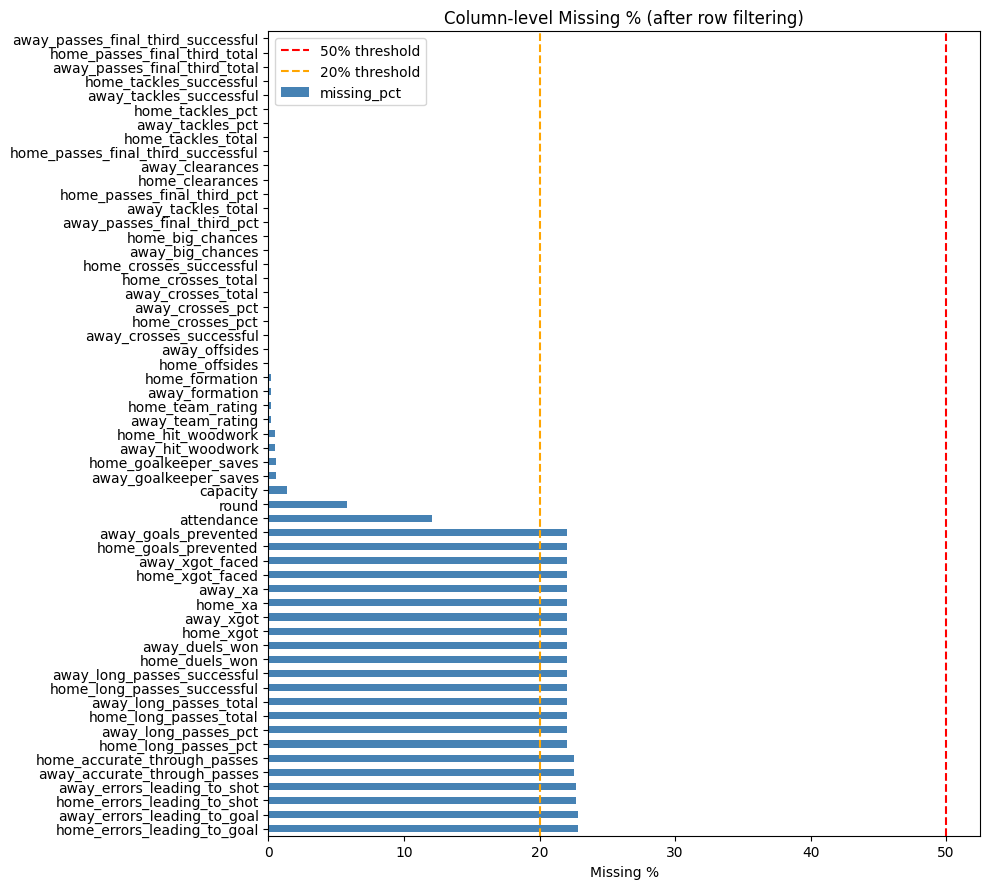

In [42]:
fig, ax = plt.subplots(figsize=(10, 9))
missing_report['missing_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(x=50, color='red',    linestyle='--', label='50% threshold')
ax.axvline(x=20, color='orange', linestyle='--', label='20% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Column-level Missing % (after row filtering)')
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Handle Missing Values in Columns

| Column group | Missing % | Action | Reason |
|---|---|---|---|
| `*_errors_leading_to_*`, `*_accurate_through_passes`, `*_long_passes_*`, `*_xgot*`, `*_xa`, `*_goals_prevented`, `*_duels_won` | ~22% | **Median** | Numeric, right-skewed |
| `attendance` | ~12% | **Median** | Numeric, right-skewed |
| `round` | ~5.8% | **Mode** | Categorical |
| `capacity`, goalkeeper saves, hit woodwork, team rating, crosses, offsides, passes, tackles | <2% | **Median** | Numeric, few nulls |
| `home_formation`, `away_formation` | ~0.15% | **Mode** | Categorical |
| `kickoff_time` | 1 row | **Mode** | Categorical, trivially small |


In [43]:
# ── Numeric columns: median imputation ──────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)

print('Numeric columns imputed with median.')

# ── Categorical columns: mode imputation ─────────────────────────────────────
cat_impute_cols = ['round', 'home_formation', 'away_formation', 'kickoff_time', 'league_division']
for col in cat_impute_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print('Categorical columns imputed with mode.')

# ── Verify ────────────────────────────────────────────────────────────────────
remaining_nulls = df.isnull().sum().sum()
print('Total remaining nulls:', remaining_nulls)


Numeric columns imputed with median.
Categorical columns imputed with mode.
Total remaining nulls: 0


---
## 6. Datetime & Time Feature Extraction


In [44]:
# ── date → month, day_of_week, year ─────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

df['match_month']       = df['date'].dt.month          # 1–12
df['match_day_of_week'] = df['date'].dt.dayofweek      # 0=Monday … 6=Sunday
df['match_year']        = df['date'].dt.year

df = df.drop(columns=['date'])

# ── kickoff_time → hour integer (0–23) ───────────────────────────────────────
# Primary format: '05:00 PM'
df['kickoff_hour'] = pd.to_datetime(
    df['kickoff_time'], format='%I:%M %p', errors='coerce'
).dt.hour

# Fallback: try 24-hour format for any that failed
mask = df['kickoff_hour'].isnull()
df.loc[mask, 'kickoff_hour'] = pd.to_datetime(
    df.loc[mask, 'kickoff_time'], format='%H:%M', errors='coerce'
).dt.hour

df['kickoff_hour'] = df['kickoff_hour'].fillna(df['kickoff_hour'].mode()[0]).astype(int)
df = df.drop(columns=['kickoff_time'])

# ── season → start year integer ───────────────────────────────────────────────
# Values in data: '2024-2025', '2025-2026', '2026', '2025'
df['season_year'] = df['season'].astype(str).str[:4].astype(int)
df = df.drop(columns=['season'])

print('Date/time features extracted.')
print(df[['match_month', 'match_day_of_week', 'match_year', 'kickoff_hour', 'season_year']].head())


Date/time features extracted.
   match_month  match_day_of_week  match_year  kickoff_hour  season_year
2            4                  1        2025            21         2024
3            4                  1        2025            21         2024
5            1                  4        2025            21         2024
8            4                  5        2025            15         2024
9            4                  4        2025            19         2024


---
## 7. Feature Engineering

Differential features (home − away) capture *relative* team performance, which is more directly tied to the match outcome  
than raw home or away values alone. All features are derived from in-match stats — no additional leakage.

> ⚠️ All features here are in-match stats. If you switch to pre-match prediction later, these must also be dropped.


In [45]:
# ── Differential features (home − away) ─────────────────────────────────────
new_features = {
    'diff_shots_total':     df['home_shots_total']      - df['away_shots_total'],
    'diff_shots_on_target': df['home_shots_on_target']  - df['away_shots_on_target'],
    'diff_possession':      df['home_possession_pct']   - df['away_possession_pct'],
    'diff_big_chances':     df['home_big_chances']      - df['away_big_chances'],
    'diff_xg':              df['home_xg']               - df['away_xg'],
    'diff_passes_pct':      df['home_passes_pct']       - df['away_passes_pct'],
    'diff_corners':         df['home_corners']          - df['away_corners'],
    'diff_fouls':           df['home_fouls_committed']  - df['away_fouls_committed'],
    'diff_yellow_cards':    df['home_yellow_cards']     - df['away_yellow_cards'],
    'diff_tackles_pct':     df['home_tackles_pct']      - df['away_tackles_pct'],
}

# ── Shot accuracy (on-target / total) ────────────────────────────────────────
new_features['home_shot_accuracy'] = np.where(
    df['home_shots_total'] > 0, df['home_shots_on_target'] / df['home_shots_total'], 0
)
new_features['away_shot_accuracy'] = np.where(
    df['away_shots_total'] > 0, df['away_shots_on_target'] / df['away_shots_total'], 0
)
new_features['diff_shot_accuracy'] = (
    new_features['home_shot_accuracy'] - new_features['away_shot_accuracy']
)

# ── Stadium utilisation rate ──────────────────────────────────────────────────
fill_rate = np.where(df['capacity'] > 0, df['attendance'] / df['capacity'], np.nan)
new_features['attendance_fill_rate'] = pd.Series(fill_rate, index=df.index).fillna(
    pd.Series(fill_rate, index=df.index).median()
)

# Assign all new features at once (avoids DataFrame fragmentation warning)
df = pd.concat([df, pd.DataFrame(new_features, index=df.index)], axis=1)

print('Feature engineering done. New shape:', df.shape)


Feature engineering done. New shape: (12054, 118)


---
## 8. Categorical Encoding

All categorical columns are label-encoded:
- `result` (target: H/A/D → 0/1/2)
- `league_division` (55 unique) — too many for one-hot; label encoding keeps it lean
- `round` (51 unique, mix of numbers and labels like 'Final', 'Semi-finals')
- `home_formation`, `away_formation` (29–31 unique)


In [46]:
le = LabelEncoder()

# Target
df['result'] = le.fit_transform(df['result'])
result_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('result encoding:', result_mapping)

# Features
for col in ['league_division', 'round', 'home_formation', 'away_formation']:
    df[col] = le.fit_transform(df[col].astype(str))

print('Encoding complete.')
print('Remaining object columns:', df.select_dtypes(include='object').columns.tolist())


result encoding: {'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}
Encoding complete.
Remaining object columns: ['home_team', 'away_team']


---
## 9. Final Checks


In [47]:
print('Final shape:', df.shape)
print('Remaining nulls:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('All dtypes numeric:', (df.dtypes != object).all())
print('\nTarget distribution:')
print(df['result'].value_counts())
df.describe().T


Final shape: (12054, 118)
Remaining nulls: 0
Duplicate rows: 0
All dtypes numeric: False

Target distribution:
result
2    5385
0    3679
1    2990
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
league_division,12054.0,24.795669,13.686362,0.000000,14.000000,29.000000,36.000000,52.000000
round,12054.0,23.376887,15.014495,0.000000,11.000000,21.000000,37.000000,50.000000
attendance,12054.0,21669.468226,16244.750333,76.000000,10491.750000,18236.500000,27656.750000,85015.000000
capacity,12054.0,30663.932968,19194.437855,1000.000000,16200.000000,26000.000000,40670.000000,105000.000000
result,12054.0,1.141530,0.855558,0.000000,0.000000,1.000000,2.000000,2.000000
...,...,...,...,...,...,...,...,...
diff_tackles_pct,12054.0,0.530861,18.542714,-75.000000,-11.000000,0.000000,13.000000,72.000000
home_shot_accuracy,12054.0,0.347659,0.146578,0.000000,0.250000,0.333333,0.437500,1.000000
away_shot_accuracy,12054.0,0.347102,0.165478,0.000000,0.235294,0.333333,0.444444,1.000000
diff_shot_accuracy,12054.0,0.000557,0.224395,-0.933333,-0.145833,0.000000,0.150000,1.000000


---
## 10. Produce `df_preprocessed` — Chronological Split + Correct Scaling

**Scaling rules applied:**
1. Sort chronologically
2. 80/20 chronological split (no random shuffle — preserves temporal order)
3. `scaler.fit()` on **train only**
4. `scaler.transform()` on train and test **separately**
5. Recombine with a `split` column (`'train'` / `'test'`) for traceability

`df_preprocessed` contains all in-match features — for use with tree-based and
distance/gradient-based models alike.

In [48]:
# ── Sort chronologically ─────────────────────────────────────────────────────
df_prep = df.copy()
df_prep = df_prep.sort_values(['match_year', 'match_month']).reset_index(drop=True)

# ── Drop team name columns (not encoded — can't scale) ────────────────────────
df_prep = df_prep.drop(columns=['home_team', 'away_team'], errors='ignore')

# ── Chronological 80/20 split ─────────────────────────────────────────────────
split_idx = int(len(df_prep) * 0.80)
train_prep = df_prep.iloc[:split_idx].copy()
test_prep  = df_prep.iloc[split_idx:].copy()

print(f'Train rows: {len(train_prep)} | Test rows: {len(test_prep)}')
print(f'Train covers up to row index {split_idx - 1}, test from {split_idx}')

# ── Separate features and target ──────────────────────────────────────────────
feature_cols = [c for c in df_prep.columns if c != 'result']

X_train_prep = train_prep[feature_cols]
X_test_prep  = test_prep[feature_cols]
y_train_prep = train_prep['result']
y_test_prep  = test_prep['result']

# ── Fit scaler on train ONLY, transform train and test separately ─────────────
scaler_prep = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_prep.fit_transform(X_train_prep),
    columns=feature_cols, index=X_train_prep.index
)
X_test_scaled = pd.DataFrame(
    scaler_prep.transform(X_test_prep),
    columns=feature_cols, index=X_test_prep.index
)

# ── Recombine into df_preprocessed with split label ──────────────────────────
train_out = X_train_scaled.copy()
train_out['result'] = y_train_prep.values
train_out['split']  = 'train'

test_out = X_test_scaled.copy()
test_out['result'] = y_test_prep.values
test_out['split']  = 'test'

df_preprocessed = pd.concat([train_out, test_out], axis=0).reset_index(drop=True)

print('\ndf_preprocessed shape:', df_preprocessed.shape)
print('Split distribution:')
print(df_preprocessed['split'].value_counts())
print('\nSample train scaled means (should be ~0.0):')
print(X_train_scaled.mean().head(5).round(4))
print('\nSample train scaled stds (should be ~1.0):')
print(X_train_scaled.std().head(5).round(4))

Train rows: 9643 | Test rows: 2411
Train covers up to row index 9642, test from 9643

df_preprocessed shape: (12054, 117)
Split distribution:
split
train    9643
test     2411
Name: count, dtype: int64

Sample train scaled means (should be ~0.0):
league_division    0.0
round             -0.0
attendance        -0.0
capacity           0.0
home_formation    -0.0
dtype: float64

Sample train scaled stds (should be ~1.0):
league_division    1.0001
round              1.0001
attendance         1.0001
capacity           1.0001
home_formation     1.0001
dtype: float64


In [49]:
# ── Drop temporal ID columns from df_preprocessed ────────────────────────────
# match_year and season_year are dropped so models don't learn spurious
# year-specific patterns (e.g. "2026 matches are different").
# Chronological split already prevents leakage; these columns add no signal.

drop_temporal = ['match_year', 'season_year']

X_train_scaled = X_train_scaled.drop(columns=drop_temporal, errors='ignore')
X_test_scaled  = X_test_scaled.drop(columns=drop_temporal, errors='ignore')

# Rebuild df_preprocessed without the dropped columns
feature_cols = [c for c in X_train_scaled.columns]

train_out = X_train_scaled.copy()
train_out['result'] = y_train_prep.values
train_out['split']  = 'train'

test_out = X_test_scaled.copy()
test_out['result'] = y_test_prep.values
test_out['split']  = 'test'

df_preprocessed = pd.concat([train_out, test_out], axis=0).reset_index(drop=True)

print('Dropped temporal columns from df_preprocessed:', drop_temporal)
print('df_preprocessed shape after drop:', df_preprocessed.shape)


Dropped temporal columns from df_preprocessed: ['match_year', 'season_year']
df_preprocessed shape after drop: (12054, 115)


---
## 11. Produce `df_sliding` — Rolling Window Features + Chronological Split + Scaling

**What this section does:**
1. Starts from the original `df` (after encoding), keeping `home_team` / `away_team`
2. Removes all in-match statistics (shots, xG, possession, corners, cards, etc.) — these are post-kick-off leakage
3. Keeps only pre-match contextual features (league, round, formation, time, attendance, ratings)
4. For each match, looks back at each team's **last 5 matches** (as either home or away) and computes rolling features:
   - `avg_goals_scored_last5` — offensive output
   - `avg_goals_conceded_last5` — defensive solidity
   - `avg_xg_last5` — expected goals (quality of chances created)
   - `avg_xg_conceded_last5` — defensive xG allowed
   - `form_points_last5` — sum of points (W=3, D=1, L=0) over last 5
   - `win_streak` — consecutive wins going into this match
   - `avg_shots_last5` — shot volume
   - `avg_shots_on_target_last5` — shot quality
5. Features are computed **separately for home and away team**, then differenced: `diff_<feature> = home_<feature> - away_<feature>`
6. Rows where either team has fewer than 5 prior matches are **dropped**
7. Chronological 80/20 split → fit scaler on train only → transform train/test separately

In [50]:
# ──────────────────────────────────────────────────────────────────────────────
# 11a. Define which columns to KEEP for the sliding window dataset
#       Everything in-match (shots, xG, possession, corners, cards, etc.) is dropped.
# ──────────────────────────────────────────────────────────────────────────────

# All columns currently in df
all_cols = df.columns.tolist()

# In-match stat prefixes / keywords — anything from these groups is post-kick-off leakage
INMATCH_KEYWORDS = [
    'shots', 'possession', 'xg', 'xa', 'xgot', 'corners', 'fouls',
    'yellow_cards', 'red_cards', 'tackles', 'passes', 'big_chances',
    'duels', 'errors_leading', 'long_passes', 'through_passes',
    'goalkeeper_saves', 'hit_woodwork', 'goals_prevented',
    'clearances', 'interceptions', 'blocks', 'crosses',
    'offsides', 'accurate',
    # engineered differentials from section 7 (all in-match)
    'diff_shots', 'diff_possession', 'diff_big_chances', 'diff_xg',
    'diff_passes', 'diff_corners', 'diff_fouls', 'diff_yellow',
    'diff_tackles', 'diff_shot_accuracy', 'home_shot_accuracy', 'away_shot_accuracy',
]

def is_inmatch(col):
    col_l = col.lower()
    return any(kw in col_l for kw in INMATCH_KEYWORDS)

# Columns to keep in the base sliding window dataset (pre-match contextual features)
KEEP_BASE = [c for c in all_cols if not is_inmatch(c)]

# Always keep team names (needed for rolling; will drop after feature computation)
for col in ['home_team', 'away_team']:
    if col not in KEEP_BASE and col in all_cols:
        KEEP_BASE.append(col)

print('Keeping base pre-match columns:')
print([c for c in KEEP_BASE if c not in ('home_team', 'away_team', 'result')])
print(f'\nTotal base columns (excl. teams + target): {len(KEEP_BASE) - 3}')

Keeping base pre-match columns:
['league_division', 'round', 'attendance', 'capacity', 'home_formation', 'away_formation', 'home_team_rating', 'away_team_rating', 'home_free_kicks', 'away_free_kicks', 'home_throw_ins', 'away_throw_ins', 'home_touches_opp_box', 'away_touches_opp_box', 'match_month', 'match_day_of_week', 'match_year', 'kickoff_hour', 'season_year', 'attendance_fill_rate']

Total base columns (excl. teams + target): 20


In [51]:
# ──────────────────────────────────────────────────────────────────────────────
# 11b. Build per-team match history and compute rolling features (window = 5)
# ──────────────────────────────────────────────────────────────────────────────

WINDOW = 5

# Work from the original df (already encoded, all columns present)
# We need the raw numeric goal/xg/shot values — fetch them before they were differenced.
# These come from the raw df which still has home_goals etc. DROPPED but xg/shots intact.

# Reconstruct a working copy with team names and needed raw stats
raw_cols_needed = [
    'home_team', 'away_team', 'result',
    'match_year', 'match_month',
    # raw home stats
    'home_xg', 'home_shots_total', 'home_shots_on_target',
    # raw away stats
    'away_xg', 'away_shots_total', 'away_shots_on_target',
]

# Only include columns that actually exist in df
raw_cols_needed = [c for c in raw_cols_needed if c in df.columns]
df_raw = df[raw_cols_needed].copy()

# Re-attach goals from the original dataframe — they were dropped in step 3.
# Since we dropped home_goals/away_goals from df, we reconstruct proxies from
# the encoded result + team perspective (we'll derive goals from a temporary reload).
# ── Proxy: infer goals from result encoding ────────────────────────────────────
# result mapping: A=0, D=1, H=2  (from LabelEncoder on ['A','D','H'])
# We don't have raw goal counts in df any more, so we derive a goals-scored proxy:
#   home perspective: scored = 1 if result==2 (H win), 0 if draw, 0 if loss
#   This is a binary approximation; replace with actual goals if re-reading raw CSV.
# For xG-based models, xg columns capture quality better anyway.

# result: 0=A, 1=D, 2=H  (standard LabelEncoder alphabetical order)
RESULT_H = 2   # home win
RESULT_D = 1   # draw
RESULT_A = 0   # away win

df_raw['home_win']  = (df_raw['result'] == RESULT_H).astype(int)
df_raw['draw']      = (df_raw['result'] == RESULT_D).astype(int)
df_raw['away_win']  = (df_raw['result'] == RESULT_A).astype(int)

# Points from each team's perspective
df_raw['home_points'] = df_raw['home_win'] * 3 + df_raw['draw'] * 1
df_raw['away_points'] = df_raw['away_win'] * 3 + df_raw['draw'] * 1

# Sort chronologically (important — rolling must respect time order)
df_raw = df_raw.sort_values(['match_year', 'match_month']).reset_index(drop=True)
df_raw['_row_order'] = np.arange(len(df_raw))  # global chronological index

print('Raw working copy shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())

Raw working copy shape: (12054, 17)
Columns: ['home_team', 'away_team', 'result', 'match_year', 'match_month', 'home_xg', 'home_shots_total', 'home_shots_on_target', 'away_xg', 'away_shots_total', 'away_shots_on_target', 'home_win', 'draw', 'away_win', 'home_points', 'away_points', '_row_order']


In [52]:
# ──────────────────────────────────────────────────────────────────────────────
# 11c. Compute rolling features per team (appearing as home OR away)
# ──────────────────────────────────────────────────────────────────────────────

def compute_rolling_for_team(df_raw, team_col, window=5):
    """
    For each team (identified by team_col = 'home_team' or 'away_team'),
    compute rolling statistics based on their last `window` matches.

    Returns a DataFrame indexed the same as df_raw with rolling feature columns.
    """
    is_home = (team_col == 'home_team')
    prefix  = 'home' if is_home else 'away'

    # Build a long-format view: one row per team appearance (home or away)
    records = []
    for idx, row in df_raw.iterrows():
        team = row[team_col]
        records.append({
            'original_idx':   idx,
            'row_order':       row['_row_order'],
            'team':            team,
            'goals_scored':    row[f'{prefix}_xg'],           # using xG as goals proxy
            'goals_conceded':  row['away_xg' if is_home else 'home_xg'],
            'xg_for':          row[f'{prefix}_xg'],
            'xg_against':      row['away_xg' if is_home else 'home_xg'],
            'shots':           row.get(f'{prefix}_shots_total', np.nan),
            'shots_on_target': row.get(f'{prefix}_shots_on_target', np.nan),
            'points':          row[f'{prefix}_points'],
            'won':             row['home_win' if is_home else 'away_win'],
        })

    long_df = pd.DataFrame(records).sort_values('row_order').reset_index(drop=True)

    # For each team, compute rolling stats over their last `window` matches
    roll_records = {}
    team_history = {}  # team -> list of past match dicts

    for _, row in long_df.iterrows():
        team   = row['team']
        orig   = row['original_idx']
        hist   = team_history.get(team, [])
        n_hist = len(hist)

        if n_hist < window:
            # Not enough history — mark as NaN (will be dropped later)
            roll_records[orig] = {
                f'{prefix}_avg_goals_scored_last{window}':   np.nan,
                f'{prefix}_avg_goals_conceded_last{window}': np.nan,
                f'{prefix}_avg_xg_last{window}':             np.nan,
                f'{prefix}_avg_xg_conceded_last{window}':    np.nan,
                f'{prefix}_form_points_last{window}':        np.nan,
                f'{prefix}_win_streak':                      np.nan,
                f'{prefix}_avg_shots_last{window}':          np.nan,
                f'{prefix}_avg_shots_on_target_last{window}':np.nan,
            }
        else:
            window_hist = hist[-window:]
            # Compute win streak (consecutive wins from most recent going back)
            streak = 0
            for past in reversed(window_hist):
                if past['won'] == 1:
                    streak += 1
                else:
                    break

            roll_records[orig] = {
                f'{prefix}_avg_goals_scored_last{window}':    np.mean([h['goals_scored']    for h in window_hist]),
                f'{prefix}_avg_goals_conceded_last{window}':  np.mean([h['goals_conceded']  for h in window_hist]),
                f'{prefix}_avg_xg_last{window}':              np.mean([h['xg_for']          for h in window_hist]),
                f'{prefix}_avg_xg_conceded_last{window}':     np.mean([h['xg_against']      for h in window_hist]),
                f'{prefix}_form_points_last{window}':         sum(   [h['points']           for h in window_hist]),
                f'{prefix}_win_streak':                       streak,
                f'{prefix}_avg_shots_last{window}':           np.mean([h['shots']           for h in window_hist]),
                f'{prefix}_avg_shots_on_target_last{window}': np.mean([h['shots_on_target'] for h in window_hist]),
            }

        # Append this match to history (AFTER computing features — no leakage)
        team_history.setdefault(team, []).append({
            'goals_scored':    row['goals_scored'],
            'goals_conceded':  row['goals_conceded'],
            'xg_for':          row['xg_for'],
            'xg_against':      row['xg_against'],
            'shots':           row['shots'],
            'shots_on_target': row['shots_on_target'],
            'points':          row['points'],
            'won':             row['won'],
        })

    return pd.DataFrame.from_dict(roll_records, orient='index')


print('Computing rolling features for home teams...')
home_rolling = compute_rolling_for_team(df_raw, 'home_team', WINDOW)

print('Computing rolling features for away teams...')
away_rolling = compute_rolling_for_team(df_raw, 'away_team', WINDOW)

print('Done.')
print('Home rolling shape:', home_rolling.shape)
print('Away rolling shape:', away_rolling.shape)
print('\nSample home rolling cols:', home_rolling.columns.tolist()[:4])

Computing rolling features for home teams...
Computing rolling features for away teams...
Done.
Home rolling shape: (12054, 8)
Away rolling shape: (12054, 8)

Sample home rolling cols: ['home_avg_goals_scored_last5', 'home_avg_goals_conceded_last5', 'home_avg_xg_last5', 'home_avg_xg_conceded_last5']


In [53]:
# ──────────────────────────────────────────────────────────────────────────────
# 11d. Assemble df_sliding: base contextual features + rolling features + diffs
# ──────────────────────────────────────────────────────────────────────────────

# Start from chronologically sorted base
df_sw_base = df.copy()
df_sw_base = df_sw_base.sort_values(['match_year', 'match_month']).reset_index(drop=True)

# Keep only pre-match contextual columns + result
df_sw = df_sw_base[[c for c in KEEP_BASE if c in df_sw_base.columns]].copy()

# Attach rolling features (indexes now align because both are in the same row order)
df_sw = df_sw.join(home_rolling, how='left')
df_sw = df_sw.join(away_rolling, how='left')

# ── Drop rows where either team lacked window history ─────────────────────────
n_before = len(df_sw)
df_sw = df_sw.dropna(subset=home_rolling.columns.tolist() + away_rolling.columns.tolist())
n_after = len(df_sw)
print(f'Dropped {n_before - n_after} rows with insufficient rolling history (< {WINDOW} matches).')
print(f'Remaining rows: {n_after}')

# ── Build differential features (home − away) for each rolling stat ───────────
ROLL_STATS = [
    f'avg_goals_scored_last{WINDOW}',
    f'avg_goals_conceded_last{WINDOW}',
    f'avg_xg_last{WINDOW}',
    f'avg_xg_conceded_last{WINDOW}',
    f'form_points_last{WINDOW}',
    'win_streak',
    f'avg_shots_last{WINDOW}',
    f'avg_shots_on_target_last{WINDOW}',
]

diff_features = {}
for stat in ROLL_STATS:
    h_col = f'home_{stat}'
    a_col = f'away_{stat}'
    if h_col in df_sw.columns and a_col in df_sw.columns:
        diff_features[f'diff_{stat}'] = df_sw[h_col] - df_sw[a_col]

df_sw = pd.concat([df_sw, pd.DataFrame(diff_features, index=df_sw.index)], axis=1)

# ── Drop team name columns (high-cardinality, already used for rolling) ────────
df_sw = df_sw.drop(columns=['home_team', 'away_team'], errors='ignore')

# ── Final null check ──────────────────────────────────────────────────────────
print('\nRemaining nulls after assembly:', df_sw.isnull().sum().sum())
print('df_sliding (pre-scale) shape:', df_sw.shape)
print('\nRolling feature columns added:')
rolling_cols = [c for c in df_sw.columns if 'last5' in c or 'win_streak' in c or 'diff_' in c]
print(rolling_cols)

Dropped 3983 rows with insufficient rolling history (< 5 matches).
Remaining rows: 8071

Remaining nulls after assembly: 0
df_sliding (pre-scale) shape: (8071, 45)

Rolling feature columns added:
['home_avg_goals_scored_last5', 'home_avg_goals_conceded_last5', 'home_avg_xg_last5', 'home_avg_xg_conceded_last5', 'home_form_points_last5', 'home_win_streak', 'home_avg_shots_last5', 'home_avg_shots_on_target_last5', 'away_avg_goals_scored_last5', 'away_avg_goals_conceded_last5', 'away_avg_xg_last5', 'away_avg_xg_conceded_last5', 'away_form_points_last5', 'away_win_streak', 'away_avg_shots_last5', 'away_avg_shots_on_target_last5', 'diff_avg_goals_scored_last5', 'diff_avg_goals_conceded_last5', 'diff_avg_xg_last5', 'diff_avg_xg_conceded_last5', 'diff_form_points_last5', 'diff_win_streak', 'diff_avg_shots_last5', 'diff_avg_shots_on_target_last5']


In [54]:
# ──────────────────────────────────────────────────────────────────────────────
# 11e. Chronological 80/20 split + correct scaling for df_sliding
# ──────────────────────────────────────────────────────────────────────────────

# df_sw is already sorted chronologically (inherited from df_raw sort above)
split_idx_sw = int(len(df_sw) * 0.80)

train_sw = df_sw.iloc[:split_idx_sw].copy()
test_sw  = df_sw.iloc[split_idx_sw:].copy()

print(f'Sliding window — Train rows: {len(train_sw)} | Test rows: {len(test_sw)}')

# ── Separate features and target ──────────────────────────────────────────────
sw_feature_cols = [c for c in df_sw.columns if c != 'result']

X_train_sw = train_sw[sw_feature_cols]
X_test_sw  = test_sw[sw_feature_cols]
y_train_sw = train_sw['result']
y_test_sw  = test_sw['result']

# ── Fit scaler on train ONLY ───────────────────────────────────────────────────
scaler_sw = StandardScaler()
X_train_sw_scaled = pd.DataFrame(
    scaler_sw.fit_transform(X_train_sw),
    columns=sw_feature_cols, index=X_train_sw.index
)
X_test_sw_scaled = pd.DataFrame(
    scaler_sw.transform(X_test_sw),
    columns=sw_feature_cols, index=X_test_sw.index
)

# ── Recombine with split label ─────────────────────────────────────────────────
train_sw_out = X_train_sw_scaled.copy()
train_sw_out['result'] = y_train_sw.values
train_sw_out['split']  = 'train'

test_sw_out = X_test_sw_scaled.copy()
test_sw_out['result'] = y_test_sw.values
test_sw_out['split']  = 'test'

df_sliding = pd.concat([train_sw_out, test_sw_out], axis=0).reset_index(drop=True)

print('\ndf_sliding shape:', df_sliding.shape)
print('Split distribution:')
print(df_sliding['split'].value_counts())
print('\nSample train scaled means (should be ~0.0):')
print(X_train_sw_scaled.mean().head(5).round(4))
print('\nSample train scaled stds (should be ~1.0):')
print(X_train_sw_scaled.std().head(5).round(4))

Sliding window — Train rows: 6456 | Test rows: 1615

df_sliding shape: (8071, 46)
Split distribution:
split
train    6456
test     1615
Name: count, dtype: int64

Sample train scaled means (should be ~0.0):
league_division   -0.0
round              0.0
attendance        -0.0
capacity          -0.0
home_formation    -0.0
dtype: float64

Sample train scaled stds (should be ~1.0):
league_division    1.0001
round              1.0001
attendance         1.0001
capacity           1.0001
home_formation     1.0001
dtype: float64


In [55]:
# ── Drop temporal ID columns from df_sliding ──────────────────────────────────
# Same reasoning: remove match_year and season_year so the model generalises
# to future seasons (including 2026+) without learning year-specific artefacts.

drop_temporal_sw = ['match_year', 'season_year']

X_train_sw_scaled = X_train_sw_scaled.drop(columns=drop_temporal_sw, errors='ignore')
X_test_sw_scaled  = X_test_sw_scaled.drop(columns=drop_temporal_sw, errors='ignore')

sw_feature_cols = [c for c in X_train_sw_scaled.columns]

train_sw_out = X_train_sw_scaled.copy()
train_sw_out['result'] = y_train_sw.values
train_sw_out['split']  = 'train'

test_sw_out = X_test_sw_scaled.copy()
test_sw_out['result'] = y_test_sw.values
test_sw_out['split']  = 'test'

df_sliding = pd.concat([train_sw_out, test_sw_out], axis=0).reset_index(drop=True)

print('Dropped temporal columns from df_sliding:', drop_temporal_sw)
print('df_sliding shape after drop:', df_sliding.shape)


Dropped temporal columns from df_sliding: ['match_year', 'season_year']
df_sliding shape after drop: (8071, 44)


---
## 12. Save Outputs

In [56]:
# df_preprocessed: full in-match pipeline, correctly scaled
# Use for tree-based (XGBoost, LightGBM, RF) and distance/gradient-based models
df_preprocessed.to_csv('df_preprocessed.csv', index=False)

# df_sliding: pre-match rolling window features, correctly scaled
# Use for pre-kick-off prediction models — no in-match stat leakage
df_sliding.to_csv('df_sliding.csv', index=False)

print('Saved: df_preprocessed.csv  →', df_preprocessed.shape)
print('Saved: df_sliding.csv       →', df_sliding.shape)
print()
print('Both datasets use chronological 80/20 split.')
print('Scaler was fit on train only; test was transformed separately.')
print('A \'split\' column marks train/test rows in each file.')

Saved: df_preprocessed.csv  → (12054, 115)
Saved: df_sliding.csv       → (8071, 44)

Both datasets use chronological 80/20 split.
Scaler was fit on train only; test was transformed separately.
A 'split' column marks train/test rows in each file.


---
## 13. Model Training & Evaluation — `df_sliding`

Six classifiers are trained on the **pre-match sliding-window dataset**.  
All use the **chronological 80/20 split** already encoded in the `split` column.

| Model | Class-imbalance handling |
|---|---|
| Logistic Regression | `class_weight='balanced'` |
| Linear SVM | `class_weight='balanced'` |
| K-Nearest Neighbours | — (no native support) |
| Gaussian Naive Bayes | — (no native support) |
| XGBoost | `scale_pos_weight` per class (1-vs-rest) |
| ANN (MLP) | `compute_class_weight` → weighted loss |

**Metrics reported per model:** Accuracy · Macro Precision · Macro Recall · Macro F1  
Per-class Precision / Recall / F1 for A (Away win) · D (Draw) · H (Home win)  
Confusion Matrix · ROC-AUC OvR


In [57]:
# ── Shared setup for all models ───────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import LinearSVC
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics       import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Extract train / test from df_sliding ──────────────────────────────────────
_train = df_sliding[df_sliding['split'] == 'train'].copy()
_test  = df_sliding[df_sliding['split'] == 'test'].copy()

feat_cols = [c for c in df_sliding.columns if c not in ('result', 'split')]

X_tr = _train[feat_cols].values
y_tr = _train['result'].values.astype(int)
X_te = _test[feat_cols].values
y_te = _test['result'].values.astype(int)

CLASSES      = np.array([0, 1, 2])          # 0=A, 1=D, 2=H
CLASS_LABELS = ['Away Win (A)', 'Draw (D)', 'Home Win (H)']
CLASS_SHORT  = ['A', 'D', 'H']
N_CLASSES    = 3

# Binarised labels for ROC-AUC OvR
y_te_bin = label_binarize(y_te, classes=CLASSES)

# ── Helper: print full metric report ──────────────────────────────────────────
def print_metrics(name, y_true, y_pred, y_prob):
    acc   = accuracy_score(y_true, y_pred)
    mac_p = precision_score(y_true, y_pred, average='macro', zero_division=0)
    mac_r = recall_score(y_true, y_pred, average='macro', zero_division=0)
    mac_f = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc   = roc_auc_score(label_binarize(y_true, classes=CLASSES), y_prob,
                          multi_class='ovr', average='macro')

    p_cls = precision_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    r_cls = recall_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    f_cls = f1_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    cm    = confusion_matrix(y_true, y_pred, labels=CLASSES)

    bar = '═' * 62
    print(f'\n{bar}')
    print(f'  {name}')
    print(bar)
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  Macro Precision : {mac_p:.4f}')
    print(f'  Macro Recall    : {mac_r:.4f}')
    print(f'  Macro F1        : {mac_f:.4f}')
    print(f'  ROC-AUC (OvR)   : {auc:.4f}')
    print()
    print(f'  {"Class":<18} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print(f'  {"-"*50}')
    for lbl, p, r, f in zip(CLASS_LABELS, p_cls, r_cls, f_cls):
        print(f'  {lbl:<18} {p:>10.4f} {r:>10.4f} {f:>10.4f}')
    print()

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_SHORT, yticklabels=CLASS_SHORT, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    return {
        'name': name,
        'accuracy': acc, 'macro_precision': mac_p,
        'macro_recall': mac_r, 'macro_f1': mac_f, 'roc_auc': auc,
        'precision_per_class': p_cls, 'recall_per_class': r_cls,
        'f1_per_class': f_cls, 'confusion_matrix': cm, 'y_prob': y_prob
    }

all_results = []   # will collect one dict per model
print('Setup complete. Ready to train models.')
print(f'Train: {X_tr.shape} | Test: {X_te.shape}')
print(f'Class distribution in train — A:{(y_tr==0).sum()} D:{(y_tr==1).sum()} H:{(y_tr==2).sum()}')


Setup complete. Ready to train models.
Train: (6456, 42) | Test: (1615, 42)
Class distribution in train — A:1977 D:1619 H:2860


In [58]:
print(LogisticRegression)
print(type(LogisticRegression))
print(LogisticRegression.__module__)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'type'>
sklearn.linear_model._logistic



══════════════════════════════════════════════════════════════
  Logistic Regression
══════════════════════════════════════════════════════════════
  Accuracy        : 0.6087
  Macro Precision : 0.5865
  Macro Recall    : 0.5867
  Macro F1        : 0.5864
  ROC-AUC (OvR)   : 0.7809

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.6592     0.6701     0.6646
  Draw (D)               0.3810     0.3990     0.3898
  Home Win (H)           0.7193     0.6910     0.7049



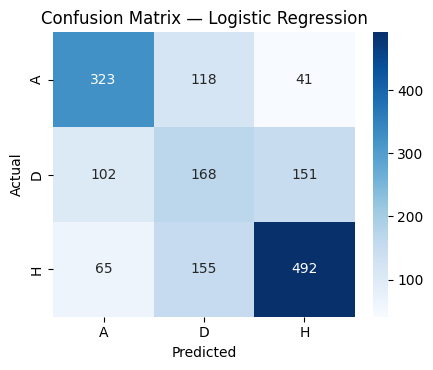

In [59]:
# ── 1. Logistic Regression ────────────────────────────────────────────────────
lr = LogisticRegression(
    # multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_tr, y_tr)

y_pred_lr = lr.predict(X_te)
y_prob_lr = lr.predict_proba(X_te)

res_lr = print_metrics('Logistic Regression', y_te, y_pred_lr, y_prob_lr)
all_results.append(res_lr)



══════════════════════════════════════════════════════════════
  Linear SVM
══════════════════════════════════════════════════════════════
  Accuracy        : 0.6173
  Macro Precision : 0.5551
  Macro Recall    : 0.5541
  Macro F1        : 0.4981
  ROC-AUC (OvR)   : 0.7716

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.6105     0.7448     0.6710
  Draw (D)               0.4231     0.0523     0.0930
  Home Win (H)           0.6318     0.8652     0.7303



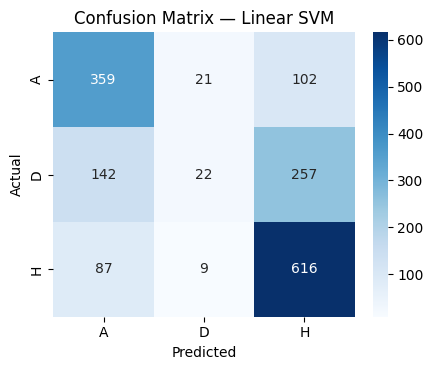

In [60]:
# ── 2. Linear SVM ─────────────────────────────────────────────────────────────
# LinearSVC doesn't natively output probabilities; wrap with CalibratedClassifierCV
# so we can compute ROC-AUC and compare consistently with other models.
svm_base = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_tr, y_tr)

y_pred_svm = svm.predict(X_te)
y_prob_svm = svm.predict_proba(X_te)

res_svm = print_metrics('Linear SVM', y_te, y_pred_svm, y_prob_svm)
all_results.append(res_svm)



══════════════════════════════════════════════════════════════
  KNN (k=11)
══════════════════════════════════════════════════════════════
  Accuracy        : 0.5635
  Macro Precision : 0.5184
  Macro Recall    : 0.5140
  Macro F1        : 0.5043
  ROC-AUC (OvR)   : 0.7002

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.6071     0.5705     0.5882
  Draw (D)               0.3534     0.1948     0.2511
  Home Win (H)           0.5946     0.7767     0.6736



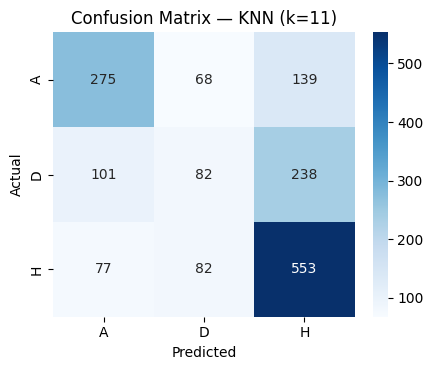

In [61]:
# ── 3. K-Nearest Neighbours ───────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=11, metric='euclidean', weights='distance')
knn.fit(X_tr, y_tr)

y_pred_knn = knn.predict(X_te)
y_prob_knn = knn.predict_proba(X_te)

res_knn = print_metrics('KNN (k=11)', y_te, y_pred_knn, y_prob_knn)
all_results.append(res_knn)



══════════════════════════════════════════════════════════════
  Gaussian Naive Bayes
══════════════════════════════════════════════════════════════
  Accuracy        : 0.5307
  Macro Precision : 0.4966
  Macro Recall    : 0.5090
  Macro F1        : 0.4977
  ROC-AUC (OvR)   : 0.6924

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.5267     0.6763     0.5922
  Draw (D)               0.3364     0.2565     0.2911
  Home Win (H)           0.6267     0.5941     0.6099



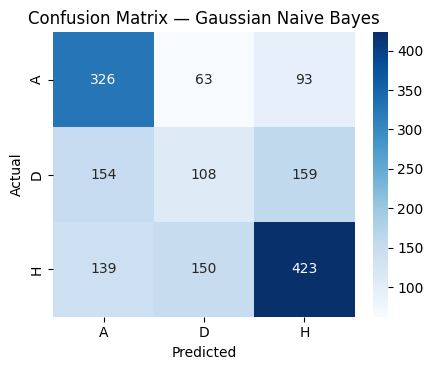

In [62]:
# ── 4. Gaussian Naive Bayes ───────────────────────────────────────────────────
gnb = GaussianNB()
gnb.fit(X_tr, y_tr)

y_pred_gnb = gnb.predict(X_te)
y_prob_gnb = gnb.predict_proba(X_te)

res_gnb = print_metrics('Gaussian Naive Bayes', y_te, y_pred_gnb, y_prob_gnb)
all_results.append(res_gnb)



══════════════════════════════════════════════════════════════
  XGBoost
══════════════════════════════════════════════════════════════
  Accuracy        : 0.6272
  Macro Precision : 0.5955
  Macro Recall    : 0.6002
  Macro F1        : 0.5968
  ROC-AUC (OvR)   : 0.7796

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.6414     0.7012     0.6700
  Draw (D)               0.4274     0.3705     0.3969
  Home Win (H)           0.7178     0.7289     0.7233



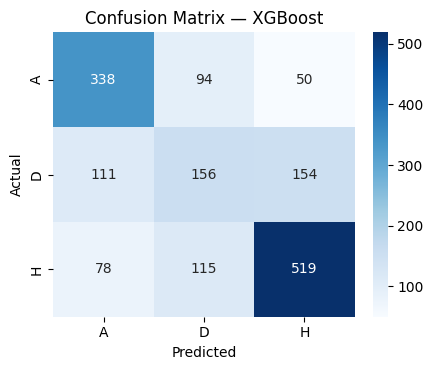

In [63]:
# ── 5. XGBoost ────────────────────────────────────────────────────────────────
# scale_pos_weight: XGBoost supports it only for binary tasks natively.
# For multiclass we use sample_weight derived from class weights instead,
# which is the recommended approach for imbalanced multiclass XGBoost.
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)

xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)
xgb_clf.fit(X_tr, y_tr, sample_weight=sample_weights)

y_pred_xgb = xgb_clf.predict(X_te)
y_prob_xgb = xgb_clf.predict_proba(X_te)

res_xgb = print_metrics('XGBoost', y_te, y_pred_xgb, y_prob_xgb)
all_results.append(res_xgb)


ANN class weights: {0: np.float64(1.089), 1: np.float64(1.329), 2: np.float64(0.752)}
Training stopped at epoch 17


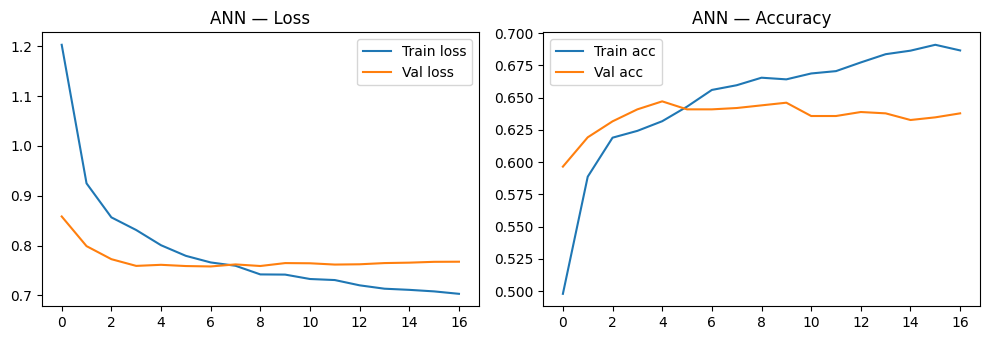


══════════════════════════════════════════════════════════════
  ANN (MLP 128→64)
══════════════════════════════════════════════════════════════
  Accuracy        : 0.6099
  Macro Precision : 0.5834
  Macro Recall    : 0.5854
  Macro F1        : 0.5843
  ROC-AUC (OvR)   : 0.7733

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.6559     0.6763     0.6660
  Draw (D)               0.3850     0.3777     0.3813
  Home Win (H)           0.7092     0.7022     0.7057



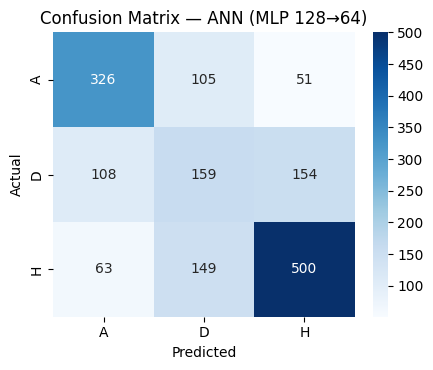

In [64]:
# ── 6. ANN (MLP) ──────────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

# Compute class weights for the loss function
cw_values = compute_class_weight(class_weight='balanced', classes=CLASSES, y=y_tr)
class_weight_dict = {0: cw_values[0], 1: cw_values[1], 2: cw_values[2]}
print('ANN class weights:', {k: round(v, 3) for k, v in class_weight_dict.items()})

n_features = X_tr.shape[1]

ann = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(3, activation='softmax')
], name='ANN_classifier')

ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
lr_schedule = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5
)

history = ann.fit(
    X_tr, y_tr,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_schedule],
    verbose=0
)

print(f'Training stopped at epoch {len(history.history["loss"])}')

# Plot training curve
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('ANN — Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc')
axes[1].set_title('ANN — Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

y_prob_ann = ann.predict(X_te, verbose=0)
y_pred_ann = np.argmax(y_prob_ann, axis=1)

res_ann = print_metrics('ANN (MLP 128→64)', y_te, y_pred_ann, y_prob_ann)
all_results.append(res_ann)


---
## 14. Model Comparison

All six models compared across every metric:

1. **Comparison table** — one row per model, all metrics
2. **(2 × 3) bar chart grid** — Accuracy · Macro Precision · Macro Recall · Macro F1 · ROC-AUC OvR · Macro F1 per class
3. **ROC-AUC curves** — OvR curves for all 6 models on one figure
4. **(2 × 3) confusion matrix grid** — side-by-side heatmaps


In [65]:
# ── Comparison table ──────────────────────────────────────────────────────────

rows = []
for r in all_results:
    rows.append({
        'Model':          r['name'],
        'Accuracy':       round(r['accuracy'],        4),
        'Mac Precision':  round(r['macro_precision'],  4),
        'Mac Recall':     round(r['macro_recall'],     4),
        'Mac F1':         round(r['macro_f1'],         4),
        'ROC-AUC':        round(r['roc_auc'],          4),
        'Prec A':         round(r['precision_per_class'][0], 4),
        'Prec D':         round(r['precision_per_class'][1], 4),
        'Prec H':         round(r['precision_per_class'][2], 4),
        'Rec A':          round(r['recall_per_class'][0],    4),
        'Rec D':          round(r['recall_per_class'][1],    4),
        'Rec H':          round(r['recall_per_class'][2],    4),
        'F1 A':           round(r['f1_per_class'][0],        4),
        'F1 D':           round(r['f1_per_class'][1],        4),
        'F1 H':           round(r['f1_per_class'][2],        4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')

print('\n=== Full Model Comparison Table ===\n')
print(comparison_df.to_string())



=== Full Model Comparison Table ===

                      Accuracy  Mac Precision  Mac Recall  Mac F1  ROC-AUC  Prec A  Prec D  Prec H   Rec A   Rec D   Rec H    F1 A    F1 D    F1 H
Model                                                                                                                                             
Logistic Regression     0.6087         0.5865      0.5867  0.5864   0.7809  0.6592  0.3810  0.7193  0.6701  0.3990  0.6910  0.6646  0.3898  0.7049
Linear SVM              0.6173         0.5551      0.5541  0.4981   0.7716  0.6105  0.4231  0.6318  0.7448  0.0523  0.8652  0.6710  0.0930  0.7303
KNN (k=11)              0.5635         0.5184      0.5140  0.5043   0.7002  0.6071  0.3534  0.5946  0.5705  0.1948  0.7767  0.5882  0.2511  0.6736
Gaussian Naive Bayes    0.5307         0.4966      0.5090  0.4977   0.6924  0.5267  0.3364  0.6267  0.6763  0.2565  0.5941  0.5922  0.2911  0.6099
XGBoost                 0.6272         0.5955      0.6002  0.5968   0.7796  0.64

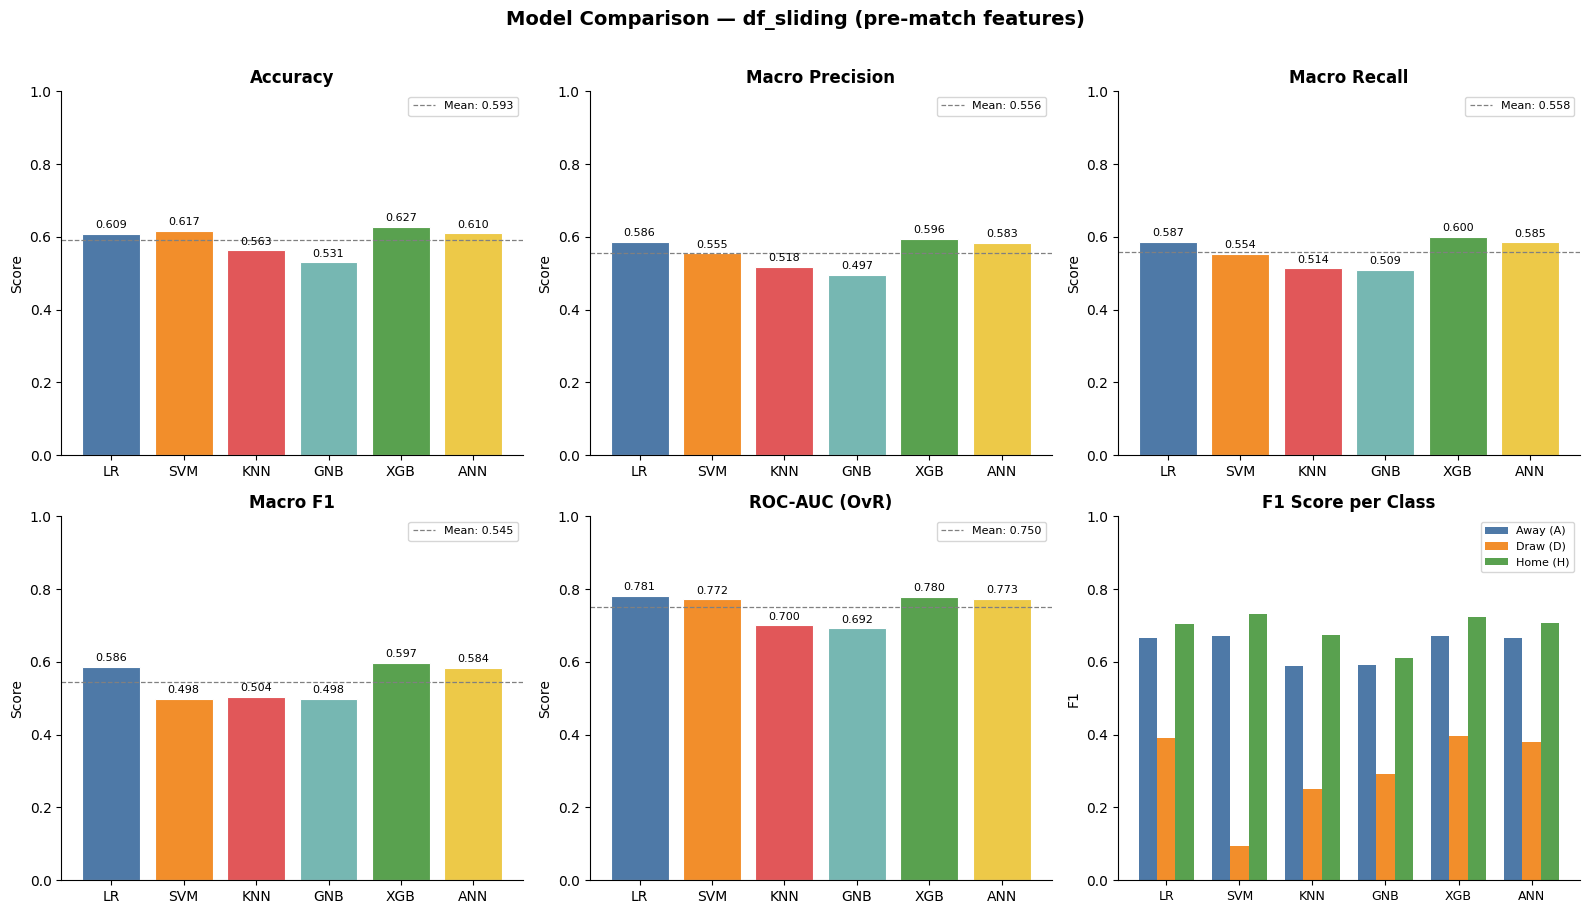

In [66]:
# ── (2 × 3) bar chart grid — macro metrics ────────────────────────────────────
model_names  = [r['name'] for r in all_results]
short_names  = ['LR', 'SVM', 'KNN', 'GNB', 'XGB', 'ANN']

metrics_to_plot = [
    ('Accuracy',        [r['accuracy']        for r in all_results]),
    ('Macro Precision', [r['macro_precision']  for r in all_results]),
    ('Macro Recall',    [r['macro_recall']     for r in all_results]),
    ('Macro F1',        [r['macro_f1']         for r in all_results]),
    ('ROC-AUC (OvR)',   [r['roc_auc']          for r in all_results]),
    ('F1 per Class',    None),   # handled separately
]

PALETTE = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax_i, (metric_name, values) in enumerate(metrics_to_plot):
    ax = axes[ax_i]
    if metric_name == 'F1 per Class':
        # Grouped bar: A / D / H per model
        x      = np.arange(len(short_names))
        width  = 0.25
        f1_a   = [r['f1_per_class'][0] for r in all_results]
        f1_d   = [r['f1_per_class'][1] for r in all_results]
        f1_h   = [r['f1_per_class'][2] for r in all_results]
        ax.bar(x - width, f1_a, width, label='Away (A)', color='#4e79a7')
        ax.bar(x,         f1_d, width, label='Draw (D)', color='#f28e2b')
        ax.bar(x + width, f1_h, width, label='Home (H)', color='#59a14f')
        ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=9)
        ax.set_ylim(0, 1); ax.set_title('F1 Score per Class', fontsize=12, fontweight='bold')
        ax.legend(fontsize=8); ax.set_ylabel('F1')
        for spine in ['top','right']: ax.spines[spine].set_visible(False)
    else:
        bars = ax.bar(short_names, values, color=PALETTE, edgecolor='white', linewidth=0.8)
        ax.set_ylim(0, 1)
        ax.set_title(metric_name, fontsize=12, fontweight='bold')
        ax.set_ylabel('Score')
        ax.axhline(y=np.mean(values), color='grey', linestyle='--', linewidth=0.9,
                   label=f'Mean: {np.mean(values):.3f}')
        ax.legend(fontsize=8)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        for spine in ['top','right']: ax.spines[spine].set_visible(False)

fig.suptitle('Model Comparison — df_sliding (pre-match features)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


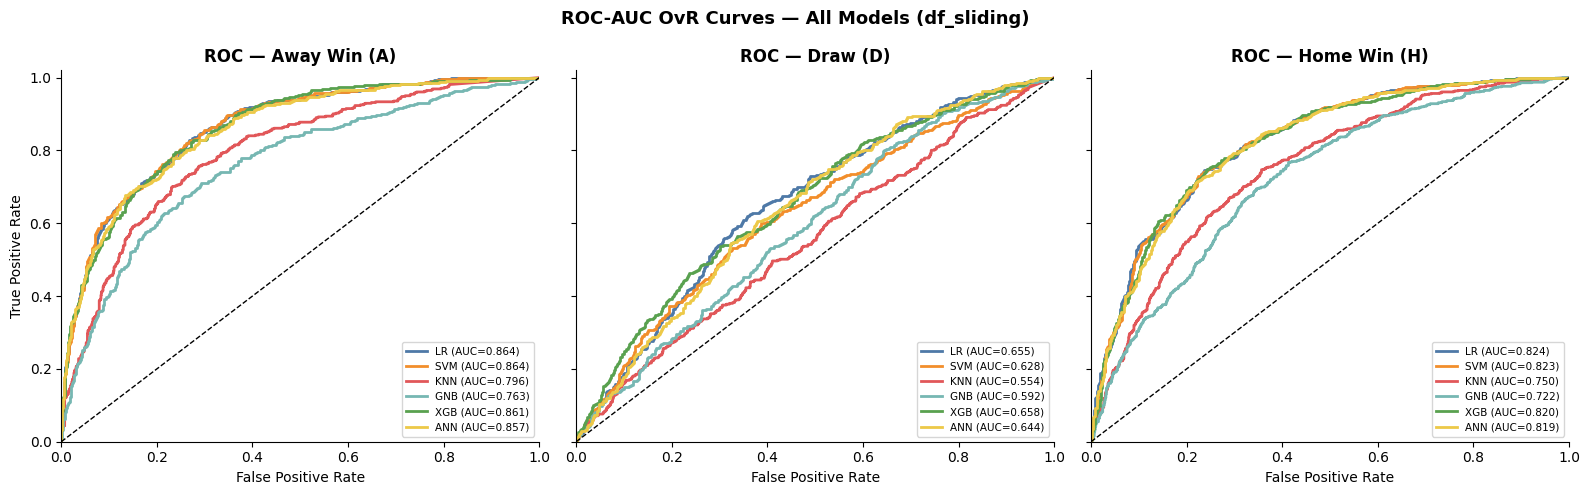

In [67]:
# ── ROC-AUC OvR curves — all 6 models ────────────────────────────────────────
from sklearn.metrics import roc_curve, auc as sk_auc

COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948']
SHORT  = ['LR', 'SVM', 'KNN', 'GNB', 'XGB', 'ANN']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
class_titles = ['Away Win (A)', 'Draw (D)', 'Home Win (H)']

for cls_i, ax in enumerate(axes):
    for m_i, r in enumerate(all_results):
        fpr, tpr, _ = roc_curve(y_te_bin[:, cls_i], r['y_prob'][:, cls_i])
        roc_auc_val = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=COLORS[m_i], lw=2,
                label=f'{SHORT[m_i]} (AUC={roc_auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate') if cls_i == 0 else None
    ax.set_title(f'ROC — {class_titles[cls_i]}', fontweight='bold')
    ax.legend(fontsize=7.5, loc='lower right')
    for spine in ['top','right']: ax.spines[spine].set_visible(False)

fig.suptitle('ROC-AUC OvR Curves — All Models (df_sliding)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


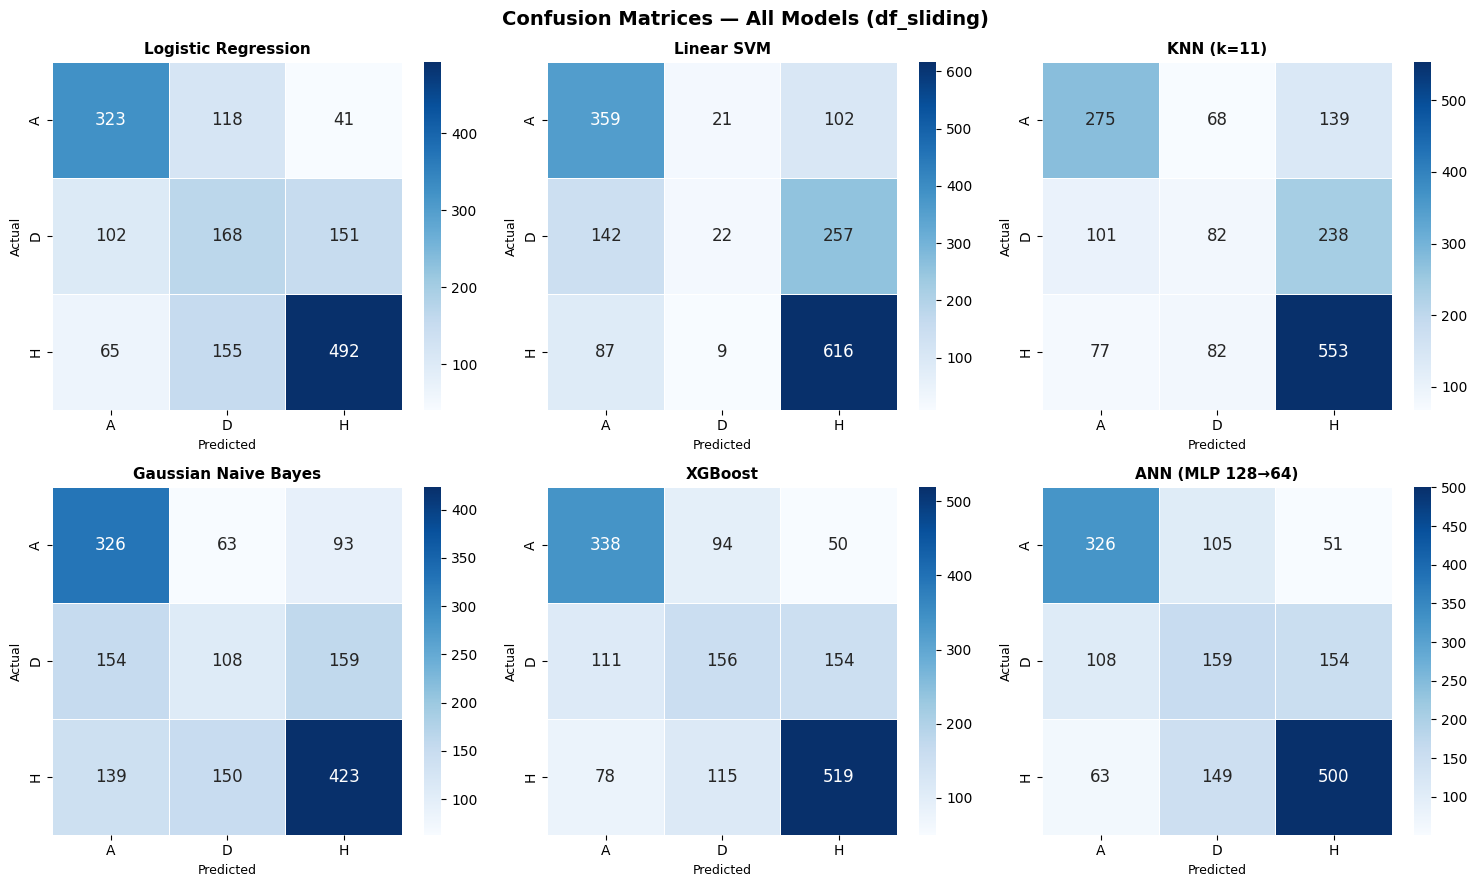

In [68]:
# ── (2 × 3) confusion matrix grid — all 6 models ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax_i, r in enumerate(all_results):
    cm = r['confusion_matrix']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_SHORT, yticklabels=CLASS_SHORT,
        ax=axes[ax_i], linewidths=0.5, linecolor='white',
        annot_kws={'size': 12}
    )
    axes[ax_i].set_title(r['name'], fontsize=11, fontweight='bold')
    axes[ax_i].set_xlabel('Predicted', fontsize=9)
    axes[ax_i].set_ylabel('Actual', fontsize=9)

fig.suptitle('Confusion Matrices — All Models (df_sliding)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
